In [1]:
import torch
from torch import Tensor
import numpy as np 
import matplotlib.pyplot as plt 
import os
import pandas as pd
import h5py as h5
print(h5.__version__)

3.13.0


# MoDL testing

In [3]:
with h5.File('/mnt/banana/student/ptrang/diffusion_model/data/mri/dataset.hdf5') as f:
    print(f.keys())

<KeysViewHDF5 ['trnCsm', 'trnMask', 'trnOrg', 'tstCsm', 'tstMask', 'tstOrg']>


In [6]:
from torch.utils.data import Dataset, ConcatDataset

trainset, testset = {}, {}

with h5.File('/mnt/banana/student/ptrang/diffusion_model/data/mri/dataset.hdf5') as f:

    trainset['org'] = f['trnOrg'][:]
    trainset['csm'] = f['trnCsm'][:]
    trainset['mask'] = f['trnMask'][:]

    testset['org'] = f['tstOrg'][:]
    testset['csm'] = f['tstCsm'][:]
    testset['mask'] = f['tstMask'][:]

trainset, testset

({'org': array([[[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          ...,
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],
  
         [[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          ...,
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],
  
         [[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.

In [12]:
trainset['org'].shape, trainset['csm'].shape, trainset['mask'].shape, testset['org'].shape

((360, 256, 232), (360, 12, 256, 232), (360, 256, 232), (164, 256, 232))

In [ ]:
def div0( a, b ):
    """ This function handles division by zero """
    c=np.divide(a, b, out=np.zeros_like(a), where=b!=0)
    return c

def normalize01(img):
    """
    Normalize the image between o and 1
    """
    if len(img.shape)==3:
        nimg=len(img)
    else:
        nimg=1
        r,c=img.shape
        img=np.reshape(img,(nimg,r,c))
    img2=np.empty(img.shape,dtype=img.dtype)
    for i in range(nimg):
        img2[i]=div0(img[i]-img[i].min(),np.ptp(img[i]))
        #img2[i]=(img[i]-img[i].min())/(img[i].max()-img[i].min())
    return np.squeeze(img2).astype(img.dtype)

##%%
def np_crop(data, shape=(320,320)):

    w_from = (data.shape[-2] - shape[0]) // 2
    h_from = (data.shape[-1] - shape[1]) // 2
    w_to = w_from + shape[0]
    h_to = h_from + shape[1]
    return data[..., w_from:w_to, h_from:h_to]

##%%

def myPSNR(org,recon):
    """ This function calculates PSNR between the original and
    the reconstructed     images"""
    mse=np.sum(np.square( np.abs(org-recon)))/org.size
    psnr=20*np.log10(org.max()/(np.sqrt(mse)+1e-10 ))
    return psnr


##%% Here I am reading the dataset for training and testing from dataset.hdf5 file
def getData(trnTst='testing',num=100,sigma=.01):
    #num: set this value between 0 to 163. There are total testing 164 slices in testing data
    print('Reading the data. Please wait...')
    filename='dataset.hdf5' #set the correct path here
    #filename='/Users/haggarwal/datasets/piData/dataset.hdf5'

    with h5.File(filename) as f:
        if trnTst=='training':
            org,csm,mask=f['trnOrg'][:],f['trnCsm'][:],f['trnMask'][:]
        else:
            org,csm,mask=f['tstOrg'][num],f['tstCsm'][num],f['tstMask'][num]
            na=np.newaxis
            org,csm,mask=org[na],csm[na],mask[na]
    
    print('Successfully read the data from file!')
    print('Now doing undersampling....')
    
    atb=generateUndersampled(org,csm,mask,sigma)
    print('Successfully undersampled data!')
    if trnTst=='testing':
        atb=c2r(atb)
    return org,atb,csm,mask

#Here I am reading one single image from  demoImage.hdf5 for testing demo code
def getTestingData():
    print('Reading the data. Please wait...')
    filename='demoImage.hdf5' #set the correct path here
    
    with h5.File(filename,'r') as f:
        org,csm,mask=f['tstOrg'][:],f['tstCsm'][:],f['tstMask'][:]

    
    print('Successfully read the data from file!')
    print('Now doing undersampling....')
    
    atb=generateUndersampled(org,csm,mask,sigma=.01)
    atb=c2r(atb)
    
    print('Successfully undersampled data!')
    return org,atb,csm,mask


##%%
def piA(x,csm,mask,nrow,ncol,ncoil):
    """ This is a the A operator as defined in the paper"""
    ccImg=np.reshape(x,(nrow,ncol) )
    coilImages=np.tile(ccImg,[ncoil,1,1])*csm;
    kspace=np.fft.fft2(coilImages)/np.sqrt(nrow * ncol)
    if len(mask.shape)==2:
        mask=np.tile(mask,(ncoil,1,1))
    res=kspace[mask!=0]
    return res

def piAt(kspaceUnder,csm,mask,nrow,ncol,ncoil):
    """ This is a the A^T operator as defined in the paper"""
    temp=np.zeros((ncoil,nrow,ncol),dtype=np.complex64)
    if len(mask.shape)==2:
        mask=np.tile(mask,(ncoil,1,1))

    temp[mask!=0]=kspaceUnder
    img=np.fft.ifft2(temp)*np.sqrt(nrow*ncol)
    coilComb=np.sum(img*np.conj(csm),axis=0).astype(np.complex64)
    #coilComb=coilComb.ravel();
    return coilComb

def generateUndersampled(org,csm,mask,sigma=0.):
    nSlice,ncoil,nrow,ncol=csm.shape
    atb=np.empty(org.shape,dtype=np.complex64)
    for i in range(nSlice):
        A  = lambda z: piA(z,csm[i],mask[i],nrow,ncol,ncoil)
        At = lambda z: piAt(z,csm[i],mask[i],nrow,ncol,ncoil)

        sidx=np.where(mask[i].ravel()!=0)[0]
        nSIDX=len(sidx)
        noise=np.random.randn(nSIDX*ncoil,)+1j*np.random.randn(nSIDX*ncoil,)
        noise=noise*(sigma/np.sqrt(2.))
        y=A(org[i]) + noise
        atb[i]=At(y)
    return atb


##%%
def r2c(inp):
    """  input img: row x col x 2 in float32
    output image: row  x col in complex64
    """
    if inp.dtype=='float32':
        dtype=np.complex64
    else:
        dtype=np.complex128
    out=np.zeros( inp.shape[0:2],dtype=dtype)
    out=inp[...,0]+1j*inp[...,1]
    return out

def c2r(inp):
    """  input img: row x col in complex64
    output image: row  x col x2 in float32
    """
    if inp.dtype=='complex64':
        dtype=np.float32
    else:
        dtype=np.float64
    out=np.zeros( inp.shape+(2,),dtype=dtype)
    out[...,0]=inp.real
    out[...,1]=inp.imag
    return out

# DDNM testing

In [ ]:
def color2gray(x):
    coef=1/3
    x = x[:,0,:,:] * coef + x[:,1,:,:]*coef +  x[:,2,:,:]*coef
    return x.repeat(1,3,1,1)

def gray2color(x):
    x = x[:,0,:,:]
    coef=1/3
    base = coef**2 + coef**2 + coef**2
    return torch.stack((x*coef/base, x*coef/base, x*coef/base), 1)    
    
def PatchUpsample(x, scale):
    n, c, h, w = x.shape
    x = torch.zeros(n,c,h,scale,w,scale) + x.view(n,c,h,1,w,1)
    return x.view(n,c,scale*h,scale*w)

def get_gaussian_noisy_img(img, noise_level):
    return img + torch.randn_like(img) * noise_level

def MeanUpsample(x, scale):
    n, c, h, w = x.shape
    out = torch.zeros(n, c, h, scale, w, scale).to(x.device) + x.view(n,c,h,1,w,1)
    out = out.view(n, c, scale*h, scale*w)
    return out

def NewMeanUpSample(x, scale):
    return x.repeat_interleave(scale, dim=2).repeat_interleave(scale, dim=3)

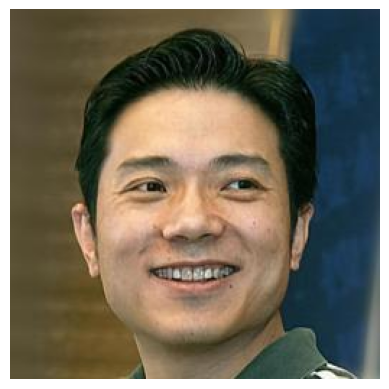

torch.Size([1, 3, 256, 256])

In [37]:
import matplotlib.image as mpimg
import torchvision.transforms as transforms

image = mpimg.imread('/mnt/banana/student/ptrang/diffusion_model/data/celeba_hq_256/00000.jpg')
plt.imshow(image)
plt.axis('off')
plt.show()

transform = transforms.ToTensor()
image_tensor = transform(image)
image_tensor = image_tensor.unsqueeze(0)
image_tensor.shape

In [38]:
gray_image = color2gray(image_tensor)
color_image = gray2color(gray_image)
patchup_image = PatchUpsample(image_tensor, 4)
gauss_noise_image = get_gaussian_noisy_img(image_tensor, 0.2)
meanup_image = MeanUpsample(image_tensor, 4)
new_meanup_image = NewMeanUpSample(image_tensor, 4)

tensor([[[[[[0.3451, 0.3451, 0.3451, 0.3451],
            [0.3451, 0.3451, 0.3451, 0.3451],
            [0.3451, 0.3451, 0.3451, 0.3451],
            ...,
            [0.1216, 0.1216, 0.1216, 0.1216],
            [0.1216, 0.1216, 0.1216, 0.1216],
            [0.1216, 0.1216, 0.1216, 0.1216]],

           [[0.3451, 0.3451, 0.3451, 0.3451],
            [0.3451, 0.3451, 0.3451, 0.3451],
            [0.3451, 0.3451, 0.3451, 0.3451],
            ...,
            [0.1216, 0.1216, 0.1216, 0.1216],
            [0.1216, 0.1216, 0.1216, 0.1216],
            [0.1216, 0.1216, 0.1216, 0.1216]],

           [[0.3451, 0.3451, 0.3451, 0.3451],
            [0.3451, 0.3451, 0.3451, 0.3451],
            [0.3451, 0.3451, 0.3451, 0.3451],
            ...,
            [0.1216, 0.1216, 0.1216, 0.1216],
            [0.1216, 0.1216, 0.1216, 0.1216],
            [0.1216, 0.1216, 0.1216, 0.1216]],

           [[0.3451, 0.3451, 0.3451, 0.3451],
            [0.3451, 0.3451, 0.3451, 0.3451],
            [0.3451, 0.

In [28]:
gray_image.shape, color_image.shape, patchup_image.shape, gauss_noise_image.shape, meanup_image.shape, new_meanup_image.shape

(torch.Size([1, 3, 256, 256]),
 torch.Size([1, 3, 256, 256]),
 torch.Size([1, 3, 1024, 1024]),
 torch.Size([1, 3, 256, 256]),
 torch.Size([1, 3, 1024, 1024]),
 torch.Size([1, 3, 1024, 1024]))

In [39]:
torch.equal(meanup_image, new_meanup_image)

True

In [32]:
def visualize(tensors):
    transform = transforms.ToPILImage()
    
    num = len(tensors)
    cols = 3
    rows = (num + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
    axes = axes.flatten()

    for i, img_tensor in enumerate(tensors):
        img = transform(img_tensor.squeeze(0))
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"Image {i+1}\nSize: {img_tensor.shape[2]}x{img_tensor.shape[3]}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


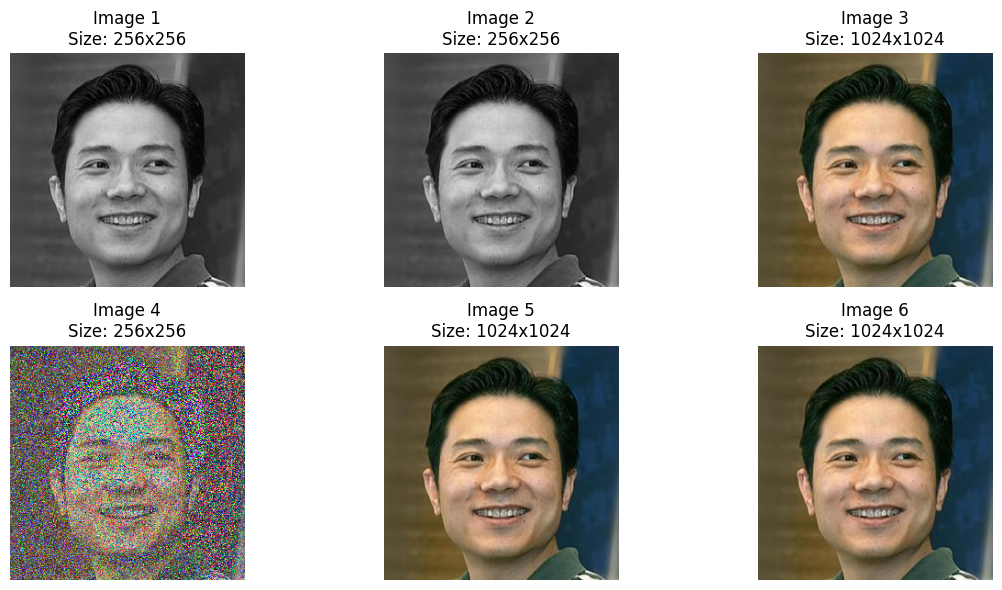

In [33]:
image_tensors = [
    gray_image, 
    color_image, 
    patchup_image, 
    gauss_noise_image, 
    meanup_image, 
    new_meanup_image
]

visualize(image_tensors)